# 04 Model Training and Evaluation

This notebook is part of the end-to-end bank loan propensity prediction and MLOps deployment project.

## Import Required Libraries

In [1]:
# Core libraries
import numpy as np
import pandas as pd

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Model selection
from sklearn.model_selection import (
    cross_validate,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV
)

# Preprocessing and pipelines
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Baseline model
from sklearn.dummy import DummyClassifier

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    HistGradientBoostingClassifier
)

# Class imbalance handling
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

# Evaluation metrics
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Save Model
import os
import joblib
from pathlib import Path

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## Load Prepared Train-Test Data

In [2]:
# ============================================================
# Load Prepared Train-Test Data
# ============================================================

train_data = pd.read_csv("../data/processed/03_train_data.csv")

test_data = pd.read_csv("../data/processed/03_test_data.csv")

print("Training Data Shape :", train_data.shape)
print("Testing Data Shape  :", test_data.shape)

Training Data Shape : (3984, 12)
Testing Data Shape  : (996, 12)


## Verify Dataset Structure

In [3]:
# Inspect Loaded Datasets

display(train_data.head())

display(test_data.head())

,Age,CustomerSince,HighestSpend,MonthlyAverageSpend,Mortgage,Level,HiddenScore,Security,FixedDepositAccount,InternetBanking,CreditCard,LoanOnCard
0,60,34,83,2.0,249,1,2,0,0,0,0,0
1,32,6,25,1.0,0,1,3,0,0,1,0,0
2,41,17,81,0.2,167,3,4,1,0,0,0,0
3,49,22,23,1.0,0,2,2,0,0,1,1,0
4,47,23,12,0.5,0,2,4,0,0,0,0,0


,Age,CustomerSince,HighestSpend,MonthlyAverageSpend,Mortgage,Level,HiddenScore,Security,FixedDepositAccount,InternetBanking,CreditCard,LoanOnCard
0,58,32,73,0.7,0,2,2,0,0,1,1,0
1,55,30,42,2.0,196,2,2,0,0,0,1,0
2,49,24,39,1.7,0,2,3,1,0,1,0,0
3,52,27,39,0.7,166,2,2,0,0,1,0,0
4,32,7,132,1.1,412,2,4,0,0,1,0,1


## Verify Data Types

In [4]:
# Feature Data Types

dtype_summary = (
    train_data.dtypes
    .reset_index()
)

dtype_summary.columns = [
    "Feature",
    "Data Type"
]

dtype_summary

,Feature,Data Type
0,Age,int64
1,CustomerSince,int64
2,HighestSpend,int64
3,MonthlyAverageSpend,float64
4,Mortgage,int64
5,Level,int64
6,HiddenScore,int64
7,Security,int64
8,FixedDepositAccount,int64
9,InternetBanking,int64


## Verify Target Variable Exists

In [5]:
# Verify Target Variable

print("Target Variable Present in Train:",
      "LoanOnCard" in train_data.columns)

print("Target Variable Present in Test:",
      "LoanOnCard" in test_data.columns)

Target Variable Present in Train: True
Target Variable Present in Test: True


## Separate Features and Target

In [6]:
# Target variable
target_col = "LoanOnCard"

# Feature matrix
X_train = train_data.drop(columns=[target_col])

X_test = test_data.drop(columns=[target_col])

# Target vectors
y_train = train_data[target_col]

y_test = test_data[target_col]

print("X_train Shape :", X_train.shape)
print("X_test Shape  :", X_test.shape)

print("y_train Shape :", y_train.shape)
print("y_test Shape  :", y_test.shape)

X_train Shape : (3984, 11)
X_test Shape  : (996, 11)
y_train Shape : (3984,)
y_test Shape  : (996,)


## Class Distribution Comparison

In [7]:
# Class Distribution Comparison

class_distribution = pd.DataFrame({
    "Train (%)": (
        y_train.value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    ),
    "Test (%)": (
        y_test.value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )
})

class_distribution.index.name = "LoanOnCard"

class_distribution

,Train (%),Test (%)
LoanOnCard,,
0,90.36,90.36
1,9.64,9.64


## Reusable Model Evaluation Framework

In [8]:
# Initialize Results Storage

model_results = []

In [9]:
# Model Evaluation Function

def evaluate_model(
    model,
    X_train,
    X_test,
    y_train,
    y_test,
    model_name
):
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Probability scores
    y_test_prob = model.predict_proba(X_test)[:, 1]
    
    # Training Metrics
    train_accuracy = accuracy_score(
        y_train,
        y_train_pred
    )
    
    # Testing Metrics
    test_accuracy = accuracy_score(
        y_test,
        y_test_pred
    )
    
    precision = precision_score(
        y_test,
        y_test_pred
    )
    
    recall = recall_score(
        y_test,
        y_test_pred
    )
    
    f1 = f1_score(
        y_test,
        y_test_pred
    )
    
    roc_auc = roc_auc_score(
        y_test,
        y_test_prob
    )
    
    cm = confusion_matrix(
        y_test,
        y_test_pred
    )
    
    tn, fp, fn, tp = cm.ravel()
    
    # Store results
    model_results.append({
    "Model": model_name,
    "Train Accuracy": round(train_accuracy, 4),
    "Test Accuracy": round(test_accuracy, 4),
    "Precision": round(precision, 4),
    "Recall": round(recall, 4),
    "F1 Score": round(f1, 4),
    "ROC-AUC": round(roc_auc, 4),
    "False Positives": fp,
    "False Negatives": fn
})
    
    print(model_name)
    
    print("\nConfusion Matrix")
    print(cm)
    
    print("\nClassification Report")
    print(
        classification_report(
            y_test,
            y_test_pred
        )
    )
    
    print("\nError Analysis")
    print(f"False Positives : {fp}")
    print(f"False Negatives : {fn}")
    
    return

## Establish Baseline Benchmark

In [10]:
# Baseline Benchmark Model: Dummy Classifier

dummy_model = DummyClassifier(
    strategy="most_frequent",
    random_state=42
)

dummy_model.fit(
    X_train,
    y_train
)

evaluate_model(
    model=dummy_model,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    model_name="Dummy Classifier - Majority Class"
)

Dummy Classifier - Majority Class

Confusion Matrix
[[900   0]
 [ 96   0]]

Classification Report
              precision    recall  f1-score   support

           0       0.90      1.00      0.95       900
           1       0.00      0.00      0.00        96

    accuracy                           0.90       996
   macro avg       0.45      0.50      0.47       996
weighted avg       0.82      0.90      0.86       996


Error Analysis
False Positives : 0
False Negatives : 96


In [11]:
# Model Results

results = pd.DataFrame(model_results)

display(results)

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC,False Positives,False Negatives
0,Dummy Classifier - Majority Class,0.9036,0.9036,0.0,0.0,0.0,0.5,0,96


## Business Interpretation

The model achieves:

90.36% Accuracy

but:

0 borrowers identified

Confusion Matrix:

| Actual | Predicted No | Predicted Yes |
|---------|-------------:|--------------:|
| No Loan | 900 | 0 |
| Loan | 96 | 0 |

It missed:

96 / 96 borrowers

Therefore:

Accuracy is not an appropriate metric for this business problem because a model can achieve over 90% accuracy while completely failing to identify potential borrowers.

## Logistic Regression (Baseline)

In [12]:
# Baseline Model 1: Logistic Regression

# Logistic Regression Pipeline

lr_baseline = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            random_state=42,
            max_iter=1000
        )
    )
])

# Train model
lr_baseline.fit(
    X_train,
    y_train
)

# Evaluate model
evaluate_model(
    model=lr_baseline,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    model_name="Logistic Regression - Baseline"
)

Logistic Regression - Baseline

Confusion Matrix
[[886  14]
 [ 41  55]]

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       900
           1       0.80      0.57      0.67        96

    accuracy                           0.94       996
   macro avg       0.88      0.78      0.82       996
weighted avg       0.94      0.94      0.94       996


Error Analysis
False Positives : 14
False Negatives : 41


In [13]:
# Model Results

results = pd.DataFrame(model_results)

display(results)

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC,False Positives,False Negatives
0,Dummy Classifier - Majority Class,0.9036,0.9036,0.0000,0.0000,0.0000,0.5000,0,96
1,Logistic Regression - Baseline,0.9536,0.9448,0.7971,0.5729,0.6667,0.9626,14,41


## Logistic Regression Baseline Interpretation:

| Actual | Predicted No | Predicted Yes |
|---------|-------------:|--------------:|
| No Loan | 886 | 14 |
| Loan | 41 | 55 |

The model correctly identified:

55 out of 96 borrowers

Recall:

55 / 96 = 57.29%

which matches the report.

## Business Perspective

Compared to the Dummy Classifier:

| Metric | Dummy Classifier | Logistic Regression |
|----------|----------------:|-------------------:|
| Accuracy | 90.36% | 94.48% |
| Recall | 0.00% | 57.29% |
| Precision | 0.00% | 79.71% |
| F1-Score | 0.00 | 0.67 |

This is a massive improvement.

The model is already finding more than half of potential borrowers while maintaining strong precision.

## Weighted Logistic Regression (Baseline)

In [14]:
# Baseline Model 2: Weighted Logistic Regression

weighted_lr = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            class_weight="balanced",
            random_state=42,
            max_iter=1000
        )
    )
])

# Train model
weighted_lr.fit(
    X_train,
    y_train
)

# Evaluate model
evaluate_model(
    model=weighted_lr,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    model_name="Weighted Logistic Regression - Baseline"
)

Weighted Logistic Regression - Baseline

Confusion Matrix
[[797 103]
 [  9  87]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.89      0.93       900
           1       0.46      0.91      0.61        96

    accuracy                           0.89       996
   macro avg       0.72      0.90      0.77       996
weighted avg       0.94      0.89      0.90       996


Error Analysis
False Positives : 103
False Negatives : 9


In [15]:
# Model Results

results = pd.DataFrame(model_results)

display(results)

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC,False Positives,False Negatives
0,Dummy Classifier - Majority Class,0.9036,0.9036,0.0000,0.0000,0.0000,0.5000,0,96
1,Logistic Regression - Baseline,0.9536,0.9448,0.7971,0.5729,0.6667,0.9626,14,41
2,Weighted Logistic Regression - Baseline,0.8976,0.8876,0.4579,0.9062,0.6084,0.9627,103,9


## Weighted Logistic Regression Baseline Interpretation:

| Actual | Predicted No | Predicted Yes |
|---------|-------------:|--------------:|
| No Loan | 797 | 103 |
| Loan | 9 | 87 |

The model now finds:

87 out of 96 borrowers

instead of:

55 out of 96 borrowers

### That's a huge improvement.

### Comparison of Missed Borrowers

| Model | False Negatives |
|--------|---------------:|
| Logistic Regression | 41 |
| Weighted Logistic Regression | 9 |

### Business Interpretation

For this project:

The bank wants to identify potential borrowers for targeted marketing campaigns.

#### Missing a borrower means:

Lost opportunity

#### While contacting a non-borrower means:

Marketing cost

#### Therefore:

Recall is more important than Accuracy.

This is why Weighted Logistic Regression often performs very well in banking campaigns.

## Naive Bayes (Baseline)

In [16]:
# Baseline Model 3: Naive Bayes

naive_bayes = GaussianNB()

naive_bayes.fit(
    X_train,
    y_train
)

evaluate_model(
    model=naive_bayes,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    model_name="Naive Bayes - Baseline"
)

Naive Bayes - Baseline

Confusion Matrix
[[818  82]
 [ 49  47]]

Classification Report
              precision    recall  f1-score   support

           0       0.94      0.91      0.93       900
           1       0.36      0.49      0.42        96

    accuracy                           0.87       996
   macro avg       0.65      0.70      0.67       996
weighted avg       0.89      0.87      0.88       996


Error Analysis
False Positives : 82
False Negatives : 49


In [17]:
# Model Results

results = pd.DataFrame(model_results)

display(results)

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC,False Positives,False Negatives
0,Dummy Classifier - Majority Class,0.9036,0.9036,0.0000,0.0000,0.0000,0.5000,0,96
1,Logistic Regression - Baseline,0.9536,0.9448,0.7971,0.5729,0.6667,0.9626,14,41
2,Weighted Logistic Regression - Baseline,0.8976,0.8876,0.4579,0.9062,0.6084,0.9627,103,9
3,Naive Bayes - Baseline,0.8855,0.8685,0.3643,0.4896,0.4178,0.9162,82,49


## Naive Bayes Baseline Interpretation:

| Actual | Predicted No | Predicted Yes |
|---------|-------------:|--------------:|
| No Loan | 818 | 82 |
| Loan | 49 | 47 |

Naive Bayes is currently underperforming.

### Reasons are consistent with your EDA:

#### Assumption 1

Naive Bayes assumes features are independent.

Our EDA found:

Age ↔ CustomerSince
Very High Multicollinearity

which violates that assumption.

#### Assumption 2

GaussianNB assumes approximately Gaussian distributions.

Our EDA found:

| Feature | Distribution |
|----------|-------------|
| HighestSpend | Right Skewed |
| MonthlyAverageSpend | Highly Skewed |
| Mortgage | Extremely Skewed |

which also works against GaussianNB.

### Decision

At this point:

- Naive Bayes is not competitive.

But unless something surprising happens later:

Naive Bayes will not be shortlisted for tuning.

That's an evidence-based decision.

## SVM Baseline

In [18]:
# Baseline Model 4: Support Vector Machine (SVM)

svm_baseline = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        SVC(
            probability=True,
            random_state=42
        )
    )
])

# Train model
svm_baseline.fit(
    X_train,
    y_train
)

# Evaluate model
evaluate_model(
    model=svm_baseline,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    model_name="SVM - Baseline"
)

SVM - Baseline

Confusion Matrix
[[898   2]
 [ 23  73]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       900
           1       0.97      0.76      0.85        96

    accuracy                           0.97       996
   macro avg       0.97      0.88      0.92       996
weighted avg       0.97      0.97      0.97       996


Error Analysis
False Positives : 2
False Negatives : 23


In [19]:
# Model Results

results = pd.DataFrame(model_results)

display(results)

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC,False Positives,False Negatives
0,Dummy Classifier - Majority Class,0.9036,0.9036,0.0000,0.0000,0.0000,0.5000,0,96
1,Logistic Regression - Baseline,0.9536,0.9448,0.7971,0.5729,0.6667,0.9626,14,41
2,Weighted Logistic Regression - Baseline,0.8976,0.8876,0.4579,0.9062,0.6084,0.9627,103,9
3,Naive Bayes - Baseline,0.8855,0.8685,0.3643,0.4896,0.4178,0.9162,82,49
4,SVM - Baseline,0.9799,0.9749,0.9733,0.7604,0.8538,0.9951,2,23


## SVM Baseline Interpretation:

| Actual | Predicted No | Predicted Yes |
|---------|-------------:|--------------:|
| No Loan | 898 | 2 |
| Loan | 23 | 73 |

This is a very strong result.

### What SVM is doing

It correctly identifies:

- 73 borrowers

while only incorrectly targeting:

- 2 non-borrowers

That's extremely efficient.

---

### Marketing Perspective

#### Weighted Logistic Regression:

- Recall = 90.63%

captures more borrowers.

BUT:

- 103 false positives

means the bank contacts many customers unnecessarily.

---

#### SVM
Recall = 76.04%

captures fewer borrowers.

BUT:

2 false positives

is exceptionally precise.

---

### Current Leaderboard

If business objective is:
#### "Find as many borrowers as possible"

##### Leader:

Weighted Logistic Regression

Recall = 90.63%

---

If business objective is:
#### "Run efficient targeted campaigns"

##### Leader:

SVM

Precision = 97.33%
F1 = 85.38%

---

### Important Observation

Notice:

SVM Baseline

is already outperforming:
- Logistic Regression
- Naive Bayes

by a large margin.

This makes SVM a strong candidate for later tuning.

---

### Decision

- No changes needed.

- SVM should definitely be shortlisted for hyperparameter tuning later.

## Decision Tree Baseline

In [20]:
# Baseline Model 5: Decision Tree

decision_tree = DecisionTreeClassifier(
    random_state=42
)

decision_tree.fit(
    X_train,
    y_train
)

evaluate_model(
    model=decision_tree,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    model_name="Decision Tree - Baseline"
)

Decision Tree - Baseline

Confusion Matrix
[[894   6]
 [  5  91]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       900
           1       0.94      0.95      0.94        96

    accuracy                           0.99       996
   macro avg       0.97      0.97      0.97       996
weighted avg       0.99      0.99      0.99       996


Error Analysis
False Positives : 6
False Negatives : 5


In [21]:
# Model Results

results = pd.DataFrame(model_results)

display(results)

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC,False Positives,False Negatives
0,Dummy Classifier - Majority Class,0.9036,0.9036,0.0000,0.0000,0.0000,0.5000,0,96
1,Logistic Regression - Baseline,0.9536,0.9448,0.7971,0.5729,0.6667,0.9626,14,41
2,Weighted Logistic Regression - Baseline,0.8976,0.8876,0.4579,0.9062,0.6084,0.9627,103,9
3,Naive Bayes - Baseline,0.8855,0.8685,0.3643,0.4896,0.4178,0.9162,82,49
4,SVM - Baseline,0.9799,0.9749,0.9733,0.7604,0.8538,0.9951,2,23
5,Decision Tree - Baseline,1.0000,0.9890,0.9381,0.9479,0.9430,0.9706,6,5


## Decision Tree Baseline Interpretation:

| Actual | Predicted No | Predicted Yes |
|---------|-------------:|--------------:|
| No Loan | 894 | 6 |
| Loan | 5 | 91 |

The model only missed:

5 borrowers

out of:

96 borrowers

### Before we proceed, I want to challenge the result.

Most versions of this banking dataset produce:

Decision Tree
≈ 90%–96% accuracy

Our result:
- 98.90% test accuracy
- 94.79% recall

is unusually strong.

That does NOT automatically mean leakage.

### But before moving to Random Forest, I want one additional validation.

Because:

Train Accuracy = 100%

means:

Perfect fit on training data

which is classic Decision Tree behavior.

If:

Depth = 30+
Leaves = hundreds

then the tree is memorizing patterns.

If:

Depth = 4–8
Leaves = small

then the structure is genuinely learning meaningful rules.

## Check Tree Complexity

In [22]:
# Decision Tree Complexity Check

print("Tree Depth      :", decision_tree.get_depth())
print("Number of Leaves:", decision_tree.get_n_leaves())

Tree Depth      : 12
Number of Leaves: 67


## Observation

Good News

The tree is not exploding in complexity.

### If I had seen:

Depth = 35
Leaves = 500+

I would immediately suspect severe overfitting.

But:

Depth = 12
Leaves = 67

is actually reasonable for:

3984 training observations
11 features
Train Accuracy = 100%

Normally this would concern me.

---

However:

### Overfitting Assessment

| Metric | Value |
|---------|-------:|
| Training Accuracy | 100.00% |
| Testing Accuracy | 98.90% |
| Accuracy Gap | 1.10% |

The gap is very small.

This means:
- Not much evidence of harmful overfitting.

The model generalizes surprisingly well.

## Random Forest Baseline

In [23]:
# Baseline Model 6: Random Forest

random_forest = RandomForestClassifier(
    random_state=42
)

random_forest.fit(
    X_train,
    y_train
)

evaluate_model(
    model=random_forest,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    model_name="Random Forest - Baseline"
)

Random Forest - Baseline

Confusion Matrix
[[899   1]
 [  6  90]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       900
           1       0.99      0.94      0.96        96

    accuracy                           0.99       996
   macro avg       0.99      0.97      0.98       996
weighted avg       0.99      0.99      0.99       996


Error Analysis
False Positives : 1
False Negatives : 6


In [24]:
# Model Results

results = pd.DataFrame(model_results)

display(results)

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC,False Positives,False Negatives
0,Dummy Classifier - Majority Class,0.9036,0.9036,0.0000,0.0000,0.0000,0.5000,0,96
1,Logistic Regression - Baseline,0.9536,0.9448,0.7971,0.5729,0.6667,0.9626,14,41
2,Weighted Logistic Regression - Baseline,0.8976,0.8876,0.4579,0.9062,0.6084,0.9627,103,9
3,Naive Bayes - Baseline,0.8855,0.8685,0.3643,0.4896,0.4178,0.9162,82,49
4,SVM - Baseline,0.9799,0.9749,0.9733,0.7604,0.8538,0.9951,2,23
5,Decision Tree - Baseline,1.0000,0.9890,0.9381,0.9479,0.9430,0.9706,6,5
6,Random Forest - Baseline,1.0000,0.9930,0.9890,0.9375,0.9626,0.9991,1,6


## Random Forest Baseline Interpretatioon

| Actual | Predicted No | Predicted Yes |
|---------|-------------:|--------------:|
| No Loan | 899 | 1 |
| Loan | 6 | 90 |

### Random Forest:

Multiple Trees + Bagging + Feature Sampling

reduces variance and improves generalization.

---

### Compared to Decision Tree:

#### Improvement

Comparison of False Positives

| Model | False Positives |
|--------|---------------:|
| Decision Tree | 6 |
| Random Forest | 1 |

Huge improvement.

---

### Slight Trade-Off

### Comparison of False Negatives

| Model | False Negatives |
|--------|---------------:|
| Decision Tree | 5 |
| Random Forest | 6 |

Only one additional missed borrower.

Practically negligible.

## Random Forest Complexity Check

In [25]:
# Random Forest Complexity Check

print(
    "Number of Trees:",
    random_forest.n_estimators
)

print(
    "Maximum Depth:",
    random_forest.max_depth
)

print(
    "Maximum Features:",
    random_forest.max_features
)

Number of Trees: 100
Maximum Depth: None
Maximum Features: sqrt


## Interpretation:

### Random Forest Hyperparameters

| Hyperparameter | Value | Description |
|----------------|--------|-------------|
| n_estimators | 100 | Number of decision trees in the forest. The default value in Scikit-learn provides a good balance between performance and computational efficiency. |
| max_depth | None | Trees are allowed to grow until all leaves are pure or other stopping criteria are met, enabling the model to capture complex patterns. |
| max_features | sqrt | At each split, a random subset of features equal to the square root of the total number of features is considered. This is the standard Random Forest setting and helps reduce overfitting by increasing tree diversity. |

Combined with:

### Overfitting Assessment

| Metric | Value |
|---------|-------:|
| Training Accuracy | 100.00% |
| Testing Accuracy | 99.30% |
| Accuracy Gap | 0.70% |

there is no immediate concern.

A tuned Random Forest will almost certainly remain one of our finalists.

## Hist Gradient Boosting (Baseline)

In [26]:
# Baseline Model 7: Hist Gradient Boosting

hist_gb = HistGradientBoostingClassifier(
    random_state=42
)

hist_gb.fit(
    X_train,
    y_train
)

evaluate_model(
    model=hist_gb,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    model_name="Hist Gradient Boosting - Baseline"
)

Hist Gradient Boosting - Baseline

Confusion Matrix
[[898   2]
 [  6  90]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       900
           1       0.98      0.94      0.96        96

    accuracy                           0.99       996
   macro avg       0.99      0.97      0.98       996
weighted avg       0.99      0.99      0.99       996


Error Analysis
False Positives : 2
False Negatives : 6


In [27]:
# Model Results

results = pd.DataFrame(model_results)

display(results)

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC,False Positives,False Negatives
0,Dummy Classifier - Majority Class,0.9036,0.9036,0.0000,0.0000,0.0000,0.5000,0,96
1,Logistic Regression - Baseline,0.9536,0.9448,0.7971,0.5729,0.6667,0.9626,14,41
2,Weighted Logistic Regression - Baseline,0.8976,0.8876,0.4579,0.9062,0.6084,0.9627,103,9
3,Naive Bayes - Baseline,0.8855,0.8685,0.3643,0.4896,0.4178,0.9162,82,49
4,SVM - Baseline,0.9799,0.9749,0.9733,0.7604,0.8538,0.9951,2,23
5,Decision Tree - Baseline,1.0000,0.9890,0.9381,0.9479,0.9430,0.9706,6,5
6,Random Forest - Baseline,1.0000,0.9930,0.9890,0.9375,0.9626,0.9991,1,6
7,Hist Gradient Boosting - Baseline,1.0000,0.9920,0.9783,0.9375,0.9574,0.9993,2,6


## Hist Gradient Boosting Baseline Interpretation

| Actual | Predicted No | Predicted Yes |
|---------|-------------:|--------------:|
| No Loan | 898 | 2 |
| Loan | 6 | 90 |

This is extremely important:

These two models are effectively tied.

The differences are:
- F1 Difference = 0.0052
- ROC Difference = 0.0002

That's tiny.

## AdaBoost Baseline

In [28]:
# Baseline Model 8: AdaBoost

adaboost = AdaBoostClassifier(
    random_state=42
)

adaboost.fit(
    X_train,
    y_train
)

evaluate_model(
    model=adaboost,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    model_name="AdaBoost - Baseline"
)

AdaBoost - Baseline

Confusion Matrix
[[891   9]
 [ 26  70]]

Classification Report
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       900
           1       0.89      0.73      0.80        96

    accuracy                           0.96       996
   macro avg       0.93      0.86      0.89       996
weighted avg       0.96      0.96      0.96       996


Error Analysis
False Positives : 9
False Negatives : 26


In [29]:
# Model Results

results = pd.DataFrame(model_results)

display(results)

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC,False Positives,False Negatives
0,Dummy Classifier - Majority Class,0.9036,0.9036,0.0000,0.0000,0.0000,0.5000,0,96
1,Logistic Regression - Baseline,0.9536,0.9448,0.7971,0.5729,0.6667,0.9626,14,41
2,Weighted Logistic Regression - Baseline,0.8976,0.8876,0.4579,0.9062,0.6084,0.9627,103,9
3,Naive Bayes - Baseline,0.8855,0.8685,0.3643,0.4896,0.4178,0.9162,82,49
4,SVM - Baseline,0.9799,0.9749,0.9733,0.7604,0.8538,0.9951,2,23
5,Decision Tree - Baseline,1.0000,0.9890,0.9381,0.9479,0.9430,0.9706,6,5
6,Random Forest - Baseline,1.0000,0.9930,0.9890,0.9375,0.9626,0.9991,1,6
7,Hist Gradient Boosting - Baseline,1.0000,0.9920,0.9783,0.9375,0.9574,0.9993,2,6
8,AdaBoost - Baseline,0.9671,0.9649,0.8861,0.7292,0.8000,0.9838,9,26


## AdaBoost Baseline Interpretation

| Actual | Predicted No | Predicted Yes |
|---------|-------------:|--------------:|
| No Loan | 891 | 9 |
| Loan | 26 | 70 |


AdaBoost correctly classified 891 non-borrowers and 70 borrowers 

### while making 35 total errors. 

The model produced:
- 9 false positives and 
- 26 false negatives, demonstrating a good balance between precision and recall. 

Although AdaBoost outperforms Logistic Regression and Naive Bayes, it is less effective than SVM, Decision Tree, Random Forest, and Hist Gradient Boosting in identifying borrowers.

# Baseline Model Benchmark Review


Before tuning anything, we'll formally decide:

- Which models survive?

- Which models are eliminated?

- Which models deserve tuning?

## Model Elimination

### Eliminate Immediately
- Naive Bayes

### Reason:

- Lowest F1
- Low Recall
- Poor Precision
- Poor ROC-AUC

No reason to spend tuning effort.

---

### Logistic Regression

Important:

This is where many people disagree.

I would not eliminate it completely.

Because:

Multicollinearity Experiments

still needs:
- All Features
- No Age
- No CustomerSince

Logistic Regression is the best model to evaluate that question.

So:
- Keep for experimentation
- Not for final model competition

---

### Shortlist Candidates
#### Tier 1
- Random Forest
- Hist Gradient Boosting
- Decision Tree

These are currently dominating.

#### Tier 2
- SVM
- Weighted Logistic Regression

Worth further investigation.

#### AdaBoost

Interesting result:

Recall = 72.92%
F1 = 80%

but clearly behind:
- Random Forest
- Hist GB
- Decision Tree
- SVM

I would not tune it.

## Multicollinearity Experiments

### Logistic Regression
- All Features
- No Age
- No CustomerSince

### Weighted Logistic Regression
- All Features
- No Age
- No CustomerSince

### SVM
- All Features
- No Age
- No CustomerSince

## Objective

During EDA, we found:

### Features with High Multicollinearity

| Feature | VIF |
|----------|----:|
| Age | ~76 |
| CustomerSince | ~29 |

Instead of removing variables solely based on statistical diagnostics, comparative experiments will be conducted to determine whether excluding either feature improves model performance and model stability.

### Why Start With Logistic Regression?

Because Logistic Regression is the most sensitive model among your shortlisted candidates to multicollinearity.

If Age/CustomerSince is causing issues:

Logistic Regression

↓

will reveal it first

# Alternative Feature Sets

In [30]:
# Alternative Feature Sets for Multicollinearity Experiments

# Feature Set A
features_all = X_train.columns.tolist()

# Feature Set B
features_no_age = [
    col
    for col in features_all
    if col != "Age"
]

# Feature Set C
features_no_customersince = [
    col
    for col in features_all
    if col != "CustomerSince"
]

print("All Features:", len(features_all))
print("No Age:", len(features_no_age))
print("No CustomerSince:", len(features_no_customersince))

All Features: 11
No Age: 10
No CustomerSince: 10


## Logistic Regression (No Age)

In [31]:
# Logistic Regression - No Age

lr_no_age = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            random_state=42,
            max_iter=1000
        )
    )
])

lr_no_age.fit(
    X_train[features_no_age],
    y_train
)

evaluate_model(
    model=lr_no_age,
    X_train=X_train[features_no_age],
    X_test=X_test[features_no_age],
    y_train=y_train,
    y_test=y_test,
    model_name="Logistic Regression - No Age"
)

Logistic Regression - No Age

Confusion Matrix
[[886  14]
 [ 39  57]]

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       900
           1       0.80      0.59      0.68        96

    accuracy                           0.95       996
   macro avg       0.88      0.79      0.83       996
weighted avg       0.94      0.95      0.94       996


Error Analysis
False Positives : 14
False Negatives : 39


In [32]:
# Model Results

results = pd.DataFrame(model_results)

display(results)

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC,False Positives,False Negatives
0,Dummy Classifier - Majority Class,0.9036,0.9036,0.0000,0.0000,0.0000,0.5000,0,96
1,Logistic Regression - Baseline,0.9536,0.9448,0.7971,0.5729,0.6667,0.9626,14,41
2,Weighted Logistic Regression - Baseline,0.8976,0.8876,0.4579,0.9062,0.6084,0.9627,103,9
3,Naive Bayes - Baseline,0.8855,0.8685,0.3643,0.4896,0.4178,0.9162,82,49
4,SVM - Baseline,0.9799,0.9749,0.9733,0.7604,0.8538,0.9951,2,23
5,Decision Tree - Baseline,1.0000,0.9890,0.9381,0.9479,0.9430,0.9706,6,5
6,Random Forest - Baseline,1.0000,0.9930,0.9890,0.9375,0.9626,0.9991,1,6
7,Hist Gradient Boosting - Baseline,1.0000,0.9920,0.9783,0.9375,0.9574,0.9993,2,6
8,AdaBoost - Baseline,0.9671,0.9649,0.8861,0.7292,0.8000,0.9838,9,26
9,Logistic Regression - No Age,0.9538,0.9468,0.8028,0.5938,0.6826,0.9625,14,39


## Logistic Regression (No CustomerSince)

In [33]:
# Logistic Regression - No CustomerSince

lr_no_customersince = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            random_state=42,
            max_iter=1000
        )
    )
])

lr_no_customersince.fit(
    X_train[features_no_customersince],
    y_train
)

evaluate_model(
    model=lr_no_customersince,
    X_train=X_train[features_no_customersince],
    X_test=X_test[features_no_customersince],
    y_train=y_train,
    y_test=y_test,
    model_name="Logistic Regression - No CustomerSince"
)

Logistic Regression - No CustomerSince

Confusion Matrix
[[886  14]
 [ 40  56]]

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       900
           1       0.80      0.58      0.67        96

    accuracy                           0.95       996
   macro avg       0.88      0.78      0.82       996
weighted avg       0.94      0.95      0.94       996


Error Analysis
False Positives : 14
False Negatives : 40


In [34]:
# Model Results

results = pd.DataFrame(model_results)

display(results)

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC,False Positives,False Negatives
0,Dummy Classifier - Majority Class,0.9036,0.9036,0.0000,0.0000,0.0000,0.5000,0,96
1,Logistic Regression - Baseline,0.9536,0.9448,0.7971,0.5729,0.6667,0.9626,14,41
2,Weighted Logistic Regression - Baseline,0.8976,0.8876,0.4579,0.9062,0.6084,0.9627,103,9
3,Naive Bayes - Baseline,0.8855,0.8685,0.3643,0.4896,0.4178,0.9162,82,49
4,SVM - Baseline,0.9799,0.9749,0.9733,0.7604,0.8538,0.9951,2,23
5,Decision Tree - Baseline,1.0000,0.9890,0.9381,0.9479,0.9430,0.9706,6,5
6,Random Forest - Baseline,1.0000,0.9930,0.9890,0.9375,0.9626,0.9991,1,6
7,Hist Gradient Boosting - Baseline,1.0000,0.9920,0.9783,0.9375,0.9574,0.9993,2,6
8,AdaBoost - Baseline,0.9671,0.9649,0.8861,0.7292,0.8000,0.9838,9,26
9,Logistic Regression - No Age,0.9538,0.9468,0.8028,0.5938,0.6826,0.9625,14,39


## LR No Age vs No CustomerSince Interpretation:

### Model Stability

Notice:
- All Features
- No Age
- No CustomerSince

all produced nearly identical results.

#### This means:
- Age and CustomerSince contain overlapping information.

which confirms the VIF analysis.

---

### Best Performing Version

Among the three:
- Logistic Regression - No Age

performed slightly better.

| Metric | Value |
|---------|-------:|
| Precision | 80.28% |
| Recall | 59.38% |
| F1-Score | 68.27% |

It also reduced:

False Negatives

41 → 39

which is favorable for the business objective.

---

### Decision

For Logistic Regression:

- Remove Age

- Keep CustomerSince

Reason:

Comparative experiments demonstrated that removing Age resulted in a small but consistent improvement in Recall and F1 Score while reducing false negatives. This suggests that CustomerSince captures most of the predictive information shared between the two variables.

## Weighted Logistic Regression Multicollinearity Experiment

In [35]:
# Weighted LR - No Age
weighted_lr_no_age = Pipeline([
    ("scaler", StandardScaler()),
    ("model",
     LogisticRegression(
         class_weight="balanced",
         random_state=42,
         max_iter=1000
     ))
])

weighted_lr_no_age.fit(
    X_train[features_no_age],
    y_train
)

evaluate_model(
    model=weighted_lr_no_age,
    X_train=X_train[features_no_age],
    X_test=X_test[features_no_age],
    y_train=y_train,
    y_test=y_test,
    model_name="Weighted Logistic Regression - No Age"
)

Weighted Logistic Regression - No Age

Confusion Matrix
[[797 103]
 [  9  87]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.89      0.93       900
           1       0.46      0.91      0.61        96

    accuracy                           0.89       996
   macro avg       0.72      0.90      0.77       996
weighted avg       0.94      0.89      0.90       996


Error Analysis
False Positives : 103
False Negatives : 9


In [36]:
# Model Results

results = pd.DataFrame(model_results)

display(results)

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC,False Positives,False Negatives
0,Dummy Classifier - Majority Class,0.9036,0.9036,0.0000,0.0000,0.0000,0.5000,0,96
1,Logistic Regression - Baseline,0.9536,0.9448,0.7971,0.5729,0.6667,0.9626,14,41
2,Weighted Logistic Regression - Baseline,0.8976,0.8876,0.4579,0.9062,0.6084,0.9627,103,9
3,Naive Bayes - Baseline,0.8855,0.8685,0.3643,0.4896,0.4178,0.9162,82,49
4,SVM - Baseline,0.9799,0.9749,0.9733,0.7604,0.8538,0.9951,2,23
5,Decision Tree - Baseline,1.0000,0.9890,0.9381,0.9479,0.9430,0.9706,6,5
6,Random Forest - Baseline,1.0000,0.9930,0.9890,0.9375,0.9626,0.9991,1,6
7,Hist Gradient Boosting - Baseline,1.0000,0.9920,0.9783,0.9375,0.9574,0.9993,2,6
8,AdaBoost - Baseline,0.9671,0.9649,0.8861,0.7292,0.8000,0.9838,9,26
9,Logistic Regression - No Age,0.9538,0.9468,0.8028,0.5938,0.6826,0.9625,14,39


In [37]:
# Weighted LR - No CustomerSince
weighted_lr_no_customersince = Pipeline([
    ("scaler", StandardScaler()),
    ("model",
     LogisticRegression(
         class_weight="balanced",
         random_state=42,
         max_iter=1000
     ))
])

weighted_lr_no_customersince.fit(
    X_train[features_no_customersince],
    y_train
)

evaluate_model(
    model=weighted_lr_no_customersince,
    X_train=X_train[features_no_customersince],
    X_test=X_test[features_no_customersince],
    y_train=y_train,
    y_test=y_test,
    model_name="Weighted Logistic Regression - No CustomerSince"
)

Weighted Logistic Regression - No CustomerSince

Confusion Matrix
[[796 104]
 [  9  87]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.88      0.93       900
           1       0.46      0.91      0.61        96

    accuracy                           0.89       996
   macro avg       0.72      0.90      0.77       996
weighted avg       0.94      0.89      0.90       996


Error Analysis
False Positives : 104
False Negatives : 9


In [38]:
# Model Results

results = pd.DataFrame(model_results)

display(results)

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC,False Positives,False Negatives
0,Dummy Classifier - Majority Class,0.9036,0.9036,0.0000,0.0000,0.0000,0.5000,0,96
1,Logistic Regression - Baseline,0.9536,0.9448,0.7971,0.5729,0.6667,0.9626,14,41
2,Weighted Logistic Regression - Baseline,0.8976,0.8876,0.4579,0.9062,0.6084,0.9627,103,9
3,Naive Bayes - Baseline,0.8855,0.8685,0.3643,0.4896,0.4178,0.9162,82,49
4,SVM - Baseline,0.9799,0.9749,0.9733,0.7604,0.8538,0.9951,2,23
5,Decision Tree - Baseline,1.0000,0.9890,0.9381,0.9479,0.9430,0.9706,6,5
6,Random Forest - Baseline,1.0000,0.9930,0.9890,0.9375,0.9626,0.9991,1,6
7,Hist Gradient Boosting - Baseline,1.0000,0.9920,0.9783,0.9375,0.9574,0.9993,2,6
8,AdaBoost - Baseline,0.9671,0.9649,0.8861,0.7292,0.8000,0.9838,9,26
9,Logistic Regression - No Age,0.9538,0.9468,0.8028,0.5938,0.6826,0.9625,14,39


## Weighted LR No Age vs No CustomerSince Interpretation:

This is very telling.

Removing either variable produced:

Virtually identical performance.

This means:
- Age and
- CustomerSince

are carrying almost the same information for this model.

### Decision

For Weighted Logistic Regression:

| Model Variant | False Positives | False Negatives | Recall |
|---------------|---------------:|----------------:|--------:|
| No Age | 103 | 9 | 90.62% |
| No CustomerSince | 104 | 9 | 90.62% |

The difference is microscopic.

## Conclusion

We now have evidence from:

### Logistic Regression

Best:
- No Age

### Weighted Logistic Regression

Best:
- No Age

Therefore:

Across both Logistic Regression variants, removing Age produced equal or slightly superior performance compared with retaining all features or removing CustomerSince. Consequently, CustomerSince was retained and Age was excluded for linear-model experiments.

## SVM Multicollinearity Experiment

In [39]:
# SVM — No Age
svm_no_age = Pipeline([
    ("scaler", StandardScaler()),
    ("model",
     SVC(
         probability=True,
         random_state=42
     ))
])

svm_no_age.fit(
    X_train[features_no_age],
    y_train
)

evaluate_model(
    model=svm_no_age,
    X_train=X_train[features_no_age],
    X_test=X_test[features_no_age],
    y_train=y_train,
    y_test=y_test,
    model_name="SVM - No Age"
)

SVM - No Age

Confusion Matrix
[[898   2]
 [ 23  73]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       900
           1       0.97      0.76      0.85        96

    accuracy                           0.97       996
   macro avg       0.97      0.88      0.92       996
weighted avg       0.97      0.97      0.97       996


Error Analysis
False Positives : 2
False Negatives : 23


In [40]:
# Model Results

results = pd.DataFrame(model_results)

display(results)

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC,False Positives,False Negatives
0,Dummy Classifier - Majority Class,0.9036,0.9036,0.0000,0.0000,0.0000,0.5000,0,96
1,Logistic Regression - Baseline,0.9536,0.9448,0.7971,0.5729,0.6667,0.9626,14,41
2,Weighted Logistic Regression - Baseline,0.8976,0.8876,0.4579,0.9062,0.6084,0.9627,103,9
3,Naive Bayes - Baseline,0.8855,0.8685,0.3643,0.4896,0.4178,0.9162,82,49
4,SVM - Baseline,0.9799,0.9749,0.9733,0.7604,0.8538,0.9951,2,23
5,Decision Tree - Baseline,1.0000,0.9890,0.9381,0.9479,0.9430,0.9706,6,5
6,Random Forest - Baseline,1.0000,0.9930,0.9890,0.9375,0.9626,0.9991,1,6
7,Hist Gradient Boosting - Baseline,1.0000,0.9920,0.9783,0.9375,0.9574,0.9993,2,6
8,AdaBoost - Baseline,0.9671,0.9649,0.8861,0.7292,0.8000,0.9838,9,26
9,Logistic Regression - No Age,0.9538,0.9468,0.8028,0.5938,0.6826,0.9625,14,39


In [41]:
# SVM — No CustomerSince
svm_no_customersince = Pipeline([
    ("scaler", StandardScaler()),
    ("model",
     SVC(
         probability=True,
         random_state=42
     ))
])

svm_no_customersince.fit(
    X_train[features_no_customersince],
    y_train
)

evaluate_model(
    model=svm_no_customersince,
    X_train=X_train[features_no_customersince],
    X_test=X_test[features_no_customersince],
    y_train=y_train,
    y_test=y_test,
    model_name="SVM - No CustomerSince"
)

SVM - No CustomerSince

Confusion Matrix
[[898   2]
 [ 22  74]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       900
           1       0.97      0.77      0.86        96

    accuracy                           0.98       996
   macro avg       0.97      0.88      0.92       996
weighted avg       0.98      0.98      0.97       996


Error Analysis
False Positives : 2
False Negatives : 22


In [42]:
# Model Results

results = pd.DataFrame(model_results)

display(results)

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC,False Positives,False Negatives
0,Dummy Classifier - Majority Class,0.9036,0.9036,0.0000,0.0000,0.0000,0.5000,0,96
1,Logistic Regression - Baseline,0.9536,0.9448,0.7971,0.5729,0.6667,0.9626,14,41
2,Weighted Logistic Regression - Baseline,0.8976,0.8876,0.4579,0.9062,0.6084,0.9627,103,9
3,Naive Bayes - Baseline,0.8855,0.8685,0.3643,0.4896,0.4178,0.9162,82,49
4,SVM - Baseline,0.9799,0.9749,0.9733,0.7604,0.8538,0.9951,2,23
5,Decision Tree - Baseline,1.0000,0.9890,0.9381,0.9479,0.9430,0.9706,6,5
6,Random Forest - Baseline,1.0000,0.9930,0.9890,0.9375,0.9626,0.9991,1,6
7,Hist Gradient Boosting - Baseline,1.0000,0.9920,0.9783,0.9375,0.9574,0.9993,2,6
8,AdaBoost - Baseline,0.9671,0.9649,0.8861,0.7292,0.8000,0.9838,9,26
9,Logistic Regression - No Age,0.9538,0.9468,0.8028,0.5938,0.6826,0.9625,14,39


## SVM No Age vs No CustomerSince Interpretation:

| Metric | No Age | No CustomerSince |
|---------|--------:|----------------:|
| False Positives | 2 | 2 |
| False Negatives | 23 | 22 |
| Recall | 76.04% | 77.08% |

- Both feature selection strategies produced nearly identical SVM performance.
- The number of false positives remained unchanged at 2, indicating that prediction precision was unaffected.
- Removing CustomerSince reduced false negatives from 23 to 22, resulting in a slightly higher recall.
- The recall improved from 76.04% to 77.08%, representing one additional borrower correctly identified.
- The performance difference is negligible, suggesting that Age and CustomerSince contribute highly similar information to the model.

## Interpretation

This is the type of result that happens in real projects.

There is no universal winner.

### Linear Models
### Logistic Regression
### Weighted Logistic Regression

prefer:
- Keep CustomerSince
- Drop Age

### SVM

prefers:
- Keep Age
- Drop CustomerSince

---

## Decision:

I would NOT create a different feature set for every model moving forward.

That becomes messy and hard to maintain.

Instead I would ask:

Which family is actually competing for the final model?

Current leaderboard:

### Model Performance Comparison (F1-Score)

| Model | F1-Score |
|--------|---------:|
| Random Forest | 96.26% |
| Hist Gradient Boosting | 95.74% |
| Decision Tree | 94.30% |
| SVM | 86.05% |
| Logistic Regression | 68.27% |
| Weighted Logistic Regression | 60.84% |

The likely finalists are:
- Random Forest
- Hist Gradient Boosting
- Decision Tree

All of them use:
- All Features
- and are largely unaffected by multicollinearity.

###Conclusion

Comparative multicollinearity experiments were conducted using alternative feature sets. Results showed only marginal performance differences across models, confirming that Age and CustomerSince contain highly overlapping information. Logistic Regression variants benefited slightly from removing Age, while SVM showed a small improvement when CustomerSince was removed. Since the best-performing models were tree-based and demonstrated strong performance using the complete feature set, both variables were retained for subsequent tree-based modeling experiments.

## Log Transformation Experiments

## Only for:

- Logistic Regression
- SVM

Why?

Because tree models:
- Decision Tree
- Random Forest
- Hist Gradient Boosting

do not care about skewness very much.

## Create Log-Transformed Datasets

In [43]:
# Create Log-Transformed Datasets

# Create copies to preserve original datasets

X_train_log = X_train.copy()
X_test_log = X_test.copy()

# Variables selected from skewness analysis

log_features = [
    "HighestSpend",
    "MonthlyAverageSpend",
    "Mortgage"
]

# Apply log(1 + x)

for col in log_features:
    
    X_train_log[col] = np.log1p(
        X_train_log[col]
    )
    
    X_test_log[col] = np.log1p(
        X_test_log[col]
    )

## Validate Transformation

In [44]:
# Compare Skewness Before and After Transformation

skewness_comparison = pd.DataFrame({
    
    "Original Skewness":
        X_train[log_features].skew(),
    
    "Log Skewness":
        X_train_log[log_features].skew()
})

display(
    skewness_comparison
    .round(3)
)

,Original Skewness,Log Skewness
HighestSpend,0.855,-0.404
MonthlyAverageSpend,1.595,0.337
Mortgage,2.103,0.869


## Assessment:

### HighestSpend
0.855 → -0.404

Improved substantially.

Slight overcorrection, but completely acceptable.

Keep transformed.

---

### MonthlyAverageSpend
1.595 → 0.337

Excellent.

Nearly symmetric.

Keep transformed.

---

### Mortgage
2.103 → 0.869

Huge improvement.

Still somewhat skewed, but dramatically better.

This is expected because:
- Median Mortgage = 0
- and many customers have no mortgage.

Keep transformed.

---

### Decision
- The transformation worked exactly as intended.
- Proceed

## Logistic Regression (No Age + Log Features)

In [45]:
# Logistic Regression - No Age + Log Features

lr_log = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            random_state=42,
            max_iter=1000
        )
    )
])

lr_log.fit(
    X_train_log[features_no_age],
    y_train
)

evaluate_model(
    model=lr_log,
    X_train=X_train_log[features_no_age],
    X_test=X_test_log[features_no_age],
    y_train=y_train,
    y_test=y_test,
    model_name="Logistic Regression - No Age Log Features"
)

Logistic Regression - No Age Log Features

Confusion Matrix
[[889  11]
 [ 36  60]]

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       900
           1       0.85      0.62      0.72        96

    accuracy                           0.95       996
   macro avg       0.90      0.81      0.85       996
weighted avg       0.95      0.95      0.95       996


Error Analysis
False Positives : 11
False Negatives : 36


In [46]:
# Model Results

results = pd.DataFrame(model_results)

display(results)

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC,False Positives,False Negatives
0,Dummy Classifier - Majority Class,0.9036,0.9036,0.0000,0.0000,0.0000,0.5000,0,96
1,Logistic Regression - Baseline,0.9536,0.9448,0.7971,0.5729,0.6667,0.9626,14,41
2,Weighted Logistic Regression - Baseline,0.8976,0.8876,0.4579,0.9062,0.6084,0.9627,103,9
3,Naive Bayes - Baseline,0.8855,0.8685,0.3643,0.4896,0.4178,0.9162,82,49
4,SVM - Baseline,0.9799,0.9749,0.9733,0.7604,0.8538,0.9951,2,23
5,Decision Tree - Baseline,1.0000,0.9890,0.9381,0.9479,0.9430,0.9706,6,5
6,Random Forest - Baseline,1.0000,0.9930,0.9890,0.9375,0.9626,0.9991,1,6
7,Hist Gradient Boosting - Baseline,1.0000,0.9920,0.9783,0.9375,0.9574,0.9993,2,6
8,AdaBoost - Baseline,0.9671,0.9649,0.8861,0.7292,0.8000,0.9838,9,26
9,Logistic Regression - No Age,0.9538,0.9468,0.8028,0.5938,0.6826,0.9625,14,39


## Interpretation:

### Impact of Log Transformation on Logistic Regression

| Metric | LR (No Age) | LR (No Age + Log Features) |
|---------|------------:|---------------------------:|
| Precision | 80.28% | 84.51% |
| Recall | 59.38% | 62.50% |
| F1-Score | 68.27% | 71.86% |
| False Positives | 14 | 11 |
| False Negatives | 39 | 36 |

This is a meaningful improvement.

### Borrowers Found

Before: 57 borrowers

After: 60 borrowers

Three additional borrowers identified.

---

### False Positives

Before: 14

After: 11

Fewer unnecessary marketing contacts.

---

### F1 Score

Before: 68.27%

After: 71.86%

Increase: +3.59 percentage points

For feature engineering, that's substantial.

### Decision

Retain log transformations for Logistic Regression.

At this point:

Best Logistic Regression Version: 

- Logistic Regression + No Age + Log Features

becomes the new benchmark.

## Weighted Logistic Regression (No Age + Log Features)

In [47]:
# Weighted Logistic Regression - No Age + Log Features

weighted_lr_log = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            class_weight="balanced",
            random_state=42,
            max_iter=1000
        )
    )
])

weighted_lr_log.fit(
    X_train_log[features_no_age],
    y_train
)

evaluate_model(
    model=weighted_lr_log,
    X_train=X_train_log[features_no_age],
    X_test=X_test_log[features_no_age],
    y_train=y_train,
    y_test=y_test,
    model_name="Weighted Logistic Regression - No Age Log Features"
)

Weighted Logistic Regression - No Age Log Features

Confusion Matrix
[[793 107]
 [  8  88]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.88      0.93       900
           1       0.45      0.92      0.60        96

    accuracy                           0.88       996
   macro avg       0.72      0.90      0.77       996
weighted avg       0.94      0.88      0.90       996


Error Analysis
False Positives : 107
False Negatives : 8


In [48]:
# Model Results

results = pd.DataFrame(model_results)

display(results)

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC,False Positives,False Negatives
0,Dummy Classifier - Majority Class,0.9036,0.9036,0.0000,0.0000,0.0000,0.5000,0,96
1,Logistic Regression - Baseline,0.9536,0.9448,0.7971,0.5729,0.6667,0.9626,14,41
2,Weighted Logistic Regression - Baseline,0.8976,0.8876,0.4579,0.9062,0.6084,0.9627,103,9
3,Naive Bayes - Baseline,0.8855,0.8685,0.3643,0.4896,0.4178,0.9162,82,49
4,SVM - Baseline,0.9799,0.9749,0.9733,0.7604,0.8538,0.9951,2,23
5,Decision Tree - Baseline,1.0000,0.9890,0.9381,0.9479,0.9430,0.9706,6,5
6,Random Forest - Baseline,1.0000,0.9930,0.9890,0.9375,0.9626,0.9991,1,6
7,Hist Gradient Boosting - Baseline,1.0000,0.9920,0.9783,0.9375,0.9574,0.9993,2,6
8,AdaBoost - Baseline,0.9671,0.9649,0.8861,0.7292,0.8000,0.9838,9,26
9,Logistic Regression - No Age,0.9538,0.9468,0.8028,0.5938,0.6826,0.9625,14,39


## Interpretation

This is a classic trade-off.

### Improvement

#### False Negatives

9 → 8

The model found:
- 88 borrowers
instead of
- 87 borrowers

---

### Cost

#### False Positives

103 → 107

More customers are incorrectly targeted.

---

#### F1 Score
60.84% → 60.27%

Slightly worse.

---

### Decision

Unlike Logistic Regression, the improvement here is not convincing.

#### For Weighted Logistic Regression:

##### Business Perspective

If your objective is: Maximum Recall

then:

Weighted LR Log Features wins slightly.

##### Machine Learning Perspective

If your objective is:

Best overall model quality

then:

Weighted LR No Age

remains the better version.

#### Recommendation

I would not adopt log transformations for Weighted Logistic Regression.

Reason:

The log-transformed version increased recall by one additional borrower but introduced four additional false positives and slightly reduced the F1 score. Therefore, the original weighted logistic regression feature set was retained.

## SVM + Log Features (No CustomerSince + Log Features)

In [49]:
# SVM - No CustomerSince + Log Features

svm_log = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        SVC(
            probability=True,
            random_state=42
        )
    )
])

svm_log.fit(
    X_train_log[features_no_customersince],
    y_train
)

evaluate_model(
    model=svm_log,
    X_train=X_train_log[features_no_customersince],
    X_test=X_test_log[features_no_customersince],
    y_train=y_train,
    y_test=y_test,
    model_name="SVM - No CustomerSince + Log Features"
)

SVM - No CustomerSince + Log Features

Confusion Matrix
[[896   4]
 [ 21  75]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       900
           1       0.95      0.78      0.86        96

    accuracy                           0.97       996
   macro avg       0.96      0.89      0.92       996
weighted avg       0.97      0.97      0.97       996


Error Analysis
False Positives : 4
False Negatives : 21


In [50]:
# Model Results

results = pd.DataFrame(model_results)

display(results)

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC,False Positives,False Negatives
0,Dummy Classifier - Majority Class,0.9036,0.9036,0.0000,0.0000,0.0000,0.5000,0,96
1,Logistic Regression - Baseline,0.9536,0.9448,0.7971,0.5729,0.6667,0.9626,14,41
2,Weighted Logistic Regression - Baseline,0.8976,0.8876,0.4579,0.9062,0.6084,0.9627,103,9
3,Naive Bayes - Baseline,0.8855,0.8685,0.3643,0.4896,0.4178,0.9162,82,49
4,SVM - Baseline,0.9799,0.9749,0.9733,0.7604,0.8538,0.9951,2,23
5,Decision Tree - Baseline,1.0000,0.9890,0.9381,0.9479,0.9430,0.9706,6,5
6,Random Forest - Baseline,1.0000,0.9930,0.9890,0.9375,0.9626,0.9991,1,6
7,Hist Gradient Boosting - Baseline,1.0000,0.9920,0.9783,0.9375,0.9574,0.9993,2,6
8,AdaBoost - Baseline,0.9671,0.9649,0.8861,0.7292,0.8000,0.9838,9,26
9,Logistic Regression - No Age,0.9538,0.9468,0.8028,0.5938,0.6826,0.9625,14,39


## Interpretation

Again, this is a trade-off.

### Improvement

#### False Negatives

22 → 21

One additional borrower identified.

---

### Cost

#### False Positives

2 → 4

Twice as many false positives.

---

### F1 Score
86.05% → 85.71%

Slight decrease.

### Decision

I would not adopt log transformations for SVM.

Reason:

Although log transformations increased recall marginally, they also increased false positives and reduced the overall F1 Score. Therefore, the original SVM feature set was retained.

## Class Imbalance Experiments

## Inspect Original Training Distribution

In [51]:
# Training Set Class Distribution

train_distribution = pd.DataFrame({
    "Count": y_train.value_counts(),
    "Percentage": (
        y_train.value_counts(normalize=True)
        .mul(100)
        .round(2)
    )
})

display(train_distribution)

,Count,Percentage
LoanOnCard,,
0,3600,90.36
1,384,9.64


## Apply SMOTE

In [52]:
# Apply SMOTE to Training Data

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Original Shape :", X_train.shape)
print("SMOTE Shape    :", X_train_smote.shape)

Original Shape : (3984, 11)
SMOTE Shape    : (7200, 11)


## Verify SMOTE Distribution

In [53]:
smote_distribution = pd.DataFrame({
    "Count": y_train_smote.value_counts(),
    "Percentage": (
        y_train_smote.value_counts(normalize=True)
        .mul(100)
        .round(2)
    )
})

display(smote_distribution)

,Count,Percentage
LoanOnCard,,
0,3600,50.0
1,3600,50.0


## Train Random Forest + SMOTE

In [54]:
# Random Forest + SMOTE

rf_smote = RandomForestClassifier(
    random_state=42
)

rf_smote.fit(
    X_train_smote,
    y_train_smote
)

evaluate_model(
    model=rf_smote,
    X_train=X_train_smote,
    X_test=X_test,
    y_train=y_train_smote,
    y_test=y_test,
    model_name="Random Forest + SMOTE"
)

Random Forest + SMOTE

Confusion Matrix
[[890  10]
 [  2  94]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       900
           1       0.90      0.98      0.94        96

    accuracy                           0.99       996
   macro avg       0.95      0.98      0.97       996
weighted avg       0.99      0.99      0.99       996


Error Analysis
False Positives : 10
False Negatives : 2


In [55]:
# Model Results

results = pd.DataFrame(model_results)

display(results)

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC,False Positives,False Negatives
0,Dummy Classifier - Majority Class,0.9036,0.9036,0.0000,0.0000,0.0000,0.5000,0,96
1,Logistic Regression - Baseline,0.9536,0.9448,0.7971,0.5729,0.6667,0.9626,14,41
2,Weighted Logistic Regression - Baseline,0.8976,0.8876,0.4579,0.9062,0.6084,0.9627,103,9
3,Naive Bayes - Baseline,0.8855,0.8685,0.3643,0.4896,0.4178,0.9162,82,49
4,SVM - Baseline,0.9799,0.9749,0.9733,0.7604,0.8538,0.9951,2,23
5,Decision Tree - Baseline,1.0000,0.9890,0.9381,0.9479,0.9430,0.9706,6,5
6,Random Forest - Baseline,1.0000,0.9930,0.9890,0.9375,0.9626,0.9991,1,6
7,Hist Gradient Boosting - Baseline,1.0000,0.9920,0.9783,0.9375,0.9574,0.9993,2,6
8,AdaBoost - Baseline,0.9671,0.9649,0.8861,0.7292,0.8000,0.9838,9,26
9,Logistic Regression - No Age,0.9538,0.9468,0.8028,0.5938,0.6826,0.9625,14,39


## Interpretation

### Huge Improvement

#### False Negatives:

6 → 2

The model now identifies:

94 borrowers out of 96

instead of:

90 borrowers out of 96

---

### Cost

#### False Positives:

1 → 10

The bank will contact:

9 additional non-borrowers

---

### F1 Score
96.26% → 94.00%

decreased.

This means overall balance worsened slightly.

---

### Business Perspective

### If objective is:

Find every possible borrower

Winner:

Random Forest + SMOTE

because:

Recall = 97.92%
FN = 2

---

### If objective is:

Balance precision and recall

Winner:

Random Forest Baseline

because:

F1 = 96.26%
FP = 1

---

### Important Observation

This result tells us:

SMOTE is working

The model became more aggressive toward the minority class.

## Apply SMOTE + Undersampling

In [56]:
# Apply SMOTE + Undersampling

over = SMOTE(
    sampling_strategy=0.3,
    random_state=42
)

under = RandomUnderSampler(
    sampling_strategy=0.5,
    random_state=42
)

pipeline = Pipeline([
    ("over", over),
    ("under", under)
])

X_train_hybrid, y_train_hybrid = pipeline.fit_resample(
    X_train,
    y_train
)

print(
    pd.Series(y_train_hybrid)
    .value_counts()
)

LoanOnCard
0    2160
1    1080
Name: count, dtype: int64


## Train Hybrid Random Forest

In [57]:
# Train Hybrid Random Forest

rf_hybrid = RandomForestClassifier(
    random_state=42
)

rf_hybrid.fit(
    X_train_hybrid,
    y_train_hybrid
)

evaluate_model(
    model=rf_hybrid,
    X_train=X_train_hybrid,
    X_test=X_test,
    y_train=y_train_hybrid,
    y_test=y_test,
    model_name="Random Forest + SMOTE + Undersampling"
)

Random Forest + SMOTE + Undersampling

Confusion Matrix
[[892   8]
 [  1  95]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       900
           1       0.92      0.99      0.95        96

    accuracy                           0.99       996
   macro avg       0.96      0.99      0.97       996
weighted avg       0.99      0.99      0.99       996


Error Analysis
False Positives : 8
False Negatives : 1


In [58]:
# Model Results

results = pd.DataFrame(model_results)

display(results)

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC,False Positives,False Negatives
0,Dummy Classifier - Majority Class,0.9036,0.9036,0.0000,0.0000,0.0000,0.5000,0,96
1,Logistic Regression - Baseline,0.9536,0.9448,0.7971,0.5729,0.6667,0.9626,14,41
2,Weighted Logistic Regression - Baseline,0.8976,0.8876,0.4579,0.9062,0.6084,0.9627,103,9
3,Naive Bayes - Baseline,0.8855,0.8685,0.3643,0.4896,0.4178,0.9162,82,49
4,SVM - Baseline,0.9799,0.9749,0.9733,0.7604,0.8538,0.9951,2,23
5,Decision Tree - Baseline,1.0000,0.9890,0.9381,0.9479,0.9430,0.9706,6,5
6,Random Forest - Baseline,1.0000,0.9930,0.9890,0.9375,0.9626,0.9991,1,6
7,Hist Gradient Boosting - Baseline,1.0000,0.9920,0.9783,0.9375,0.9574,0.9993,2,6
8,AdaBoost - Baseline,0.9671,0.9649,0.8861,0.7292,0.8000,0.9838,9,26
9,Logistic Regression - No Age,0.9538,0.9468,0.8028,0.5938,0.6826,0.9625,14,39


## Interpretation

### Random Forest Baseline

#### Strengths:
- Highest F1
- Highest Precision
- Lowest FP

#### Weakness:

Misses 6 borrowers

---

### Random Forest + SMOTE

#### Strengths:
- Recall improves dramatically

#### Weakness:
- False positives jump from 1 → 10

Too aggressive.

---

### Random Forest + SMOTE + Undersampling

This is interesting.

#### False Negatives

6 → 1

The model now misses only:

1 borrower out of 96

which is exceptional.

---

At the same time:

#### False Positives = 8

which is lower than pure SMOTE.

---

### Business Perspective

Remember the project objective:

Identify customers likely to convert so the marketing team can target campaigns more effectively.

#### Missing a borrower: Lost business opportunity

#### Contacting a non-borrower: Marketing cost

In banking campaigns:

False Negative is often more expensive than False Positive

because an actual borrower generates revenue.

## For this specific project:

I would advance two Random Forest candidates to tuning.

### Candidate 1
Random Forest Baseline

Reason:
- Best F1
- Best Precision

### Candidate 2
Random Forest + SMOTE + Undersampling

Reason:
- Recall = 98.96%
- False Negatives = 1

Outstanding business performance.

## Model Shortlisting & Selection for Hyperparameter Tuning

# Final Baseline Model Comparison

## What I Would Tune

I benchmarked 20 model variants, performed feature engineering validation,
performed multicollinearity experiments, performed resampling experiments,
and shortlisted only the strongest candidates for optimization.

### Random Forest

Current:

F1        = 96.26%
Recall    = 93.75%
FN        = 6
ROC-AUC   = 99.91%

This is our statistical leader.

### Random Forest + SMOTE + Undersampling

Current:

F1        = 95.48%
Recall    = 98.96%
FN        = 1
ROC-AUC   = 99.90%

This is our business leader.

### Hist Gradient Boosting

Current:

F1        = 95.74%
ROC-AUC   = 99.93%

This is our algorithmic challenger.

## Random Forest Hyperparameter Tuning

In [59]:
# Random Forest Hyperparameter Search Space

rf_param_distributions = {
    
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

# Random Forest Hyperparameter Optimization

rf = RandomForestClassifier(
    random_state=42
)

rf_random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param_distributions,
    n_iter=50,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_random_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,50
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [60]:
# Best Hyperparameters

print("Best Parameters:")
print(
    rf_random_search.best_params_
)

print("\nBest CV F1 Score:")
print(round(rf_random_search.best_score_, 4)
)

Best Parameters:
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30}

Best CV F1 Score:
0.9226


In [61]:
# Retrieve Best Model

rf_tuned = rf_random_search.best_estimator_

In [62]:
# Evaluate Tuned Random Forest

evaluate_model(
    model=rf_tuned,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    model_name="Random Forest - Tuned"
)

Random Forest - Tuned

Confusion Matrix
[[899   1]
 [  6  90]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       900
           1       0.99      0.94      0.96        96

    accuracy                           0.99       996
   macro avg       0.99      0.97      0.98       996
weighted avg       0.99      0.99      0.99       996


Error Analysis
False Positives : 1
False Negatives : 6


## Interpretation

### Tuning Produced No Improvement

This means:

Random Forest Baseline = Random Forest Tuned

on unseen test data.

### This is actually a good finding.

Many people think tuning must improve performance.

In reality:

Hyperparameter tuning validated that the default Random Forest configuration was already near-optimal for this dataset.

In [63]:
# Random Forest Tuned: Overfitting Check

train_accuracy = rf_tuned.score(X_train, y_train)
test_accuracy = rf_tuned.score(X_test, y_test)

print(f"Train Accuracy : {train_accuracy:.4f}")
print(f"Test Accuracy  : {test_accuracy:.4f}")
print(f"Accuracy Gap   : {train_accuracy - test_accuracy:.4f}")

Train Accuracy : 1.0000
Test Accuracy  : 0.9930
Accuracy Gap   : 0.0070


## Overfitting Assessment

| Metric | Value |
|---------|------:|
| Training Accuracy | 1.000 |
| Testing Accuracy | 0.993 |
| Accuracy Gap | 0.007 |

### Gap:

0.7%

This is extremely small.

### Conclusion:

The tuned Random Forest demonstrates excellent generalization performance with no meaningful evidence of overfitting.

Hyperparameter optimization using RandomizedSearchCV identified a shallower Random Forest configuration with max_depth=30 and max_features='log2'. However, evaluation on the test set revealed no measurable improvement over the baseline model. Consequently, the baseline Random Forest configuration was retained due to equivalent predictive performance and lower model selection complexity.

In [64]:
# Model Results

results = pd.DataFrame(model_results)

display(results)

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC,False Positives,False Negatives
0,Dummy Classifier - Majority Class,0.9036,0.9036,0.0000,0.0000,0.0000,0.5000,0,96
1,Logistic Regression - Baseline,0.9536,0.9448,0.7971,0.5729,0.6667,0.9626,14,41
2,Weighted Logistic Regression - Baseline,0.8976,0.8876,0.4579,0.9062,0.6084,0.9627,103,9
3,Naive Bayes - Baseline,0.8855,0.8685,0.3643,0.4896,0.4178,0.9162,82,49
4,SVM - Baseline,0.9799,0.9749,0.9733,0.7604,0.8538,0.9951,2,23
5,Decision Tree - Baseline,1.0000,0.9890,0.9381,0.9479,0.9430,0.9706,6,5
6,Random Forest - Baseline,1.0000,0.9930,0.9890,0.9375,0.9626,0.9991,1,6
7,Hist Gradient Boosting - Baseline,1.0000,0.9920,0.9783,0.9375,0.9574,0.9993,2,6
8,AdaBoost - Baseline,0.9671,0.9649,0.8861,0.7292,0.8000,0.9838,9,26
9,Logistic Regression - No Age,0.9538,0.9468,0.8028,0.5938,0.6826,0.9625,14,39


## Random Forest + SMOTE + Undersampling Tuning

In [65]:
# Random Forest + SMOTE + Undersampling Hyperparameter Tuning

rf_hybrid_model = RandomForestClassifier(
    random_state=42
)

rf_hybrid_random_search = RandomizedSearchCV(
    estimator=rf_hybrid_model,
    param_distributions=rf_param_distributions,
    n_iter=50,
    scoring="recall",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_hybrid_random_search.fit(
    X_train_hybrid,
    y_train_hybrid
)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,50
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [66]:
# Best Hyperparameters for Hybrid Random Forest

print("Best Parameters:")
print(rf_hybrid_random_search.best_params_)

print("\nBest CV Recall Score:")
print(round(rf_hybrid_random_search.best_score_, 4))

Best Parameters:
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30}

Best CV Recall Score:
0.9602


In [67]:
# Retrieve Best Hybrid Random Forest Model

rf_hybrid_tuned = rf_hybrid_random_search.best_estimator_

In [68]:
# Evaluate Tuned Random Forest + SMOTE + Undersampling

evaluate_model(
    model=rf_hybrid_tuned,
    X_train=X_train_hybrid,
    X_test=X_test,
    y_train=y_train_hybrid,
    y_test=y_test,
    model_name="Random Forest + SMOTE + Undersampling - Tuned"
)

Random Forest + SMOTE + Undersampling - Tuned

Confusion Matrix
[[892   8]
 [  1  95]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       900
           1       0.92      0.99      0.95        96

    accuracy                           0.99       996
   macro avg       0.96      0.99      0.97       996
weighted avg       0.99      0.99      0.99       996


Error Analysis
False Positives : 8
False Negatives : 1


## Interpretation

Exactly like the original Random Forest:

Hyperparameter tuning produced
NO measurable improvement.

### This means:

The hybrid model was already near-optimal.
The resampling strategy contributed more than hyperparameter optimization.
Model performance is being driven primarily by data preparation rather than parameter changes.

In [69]:
# Overfitting Assessment

train_accuracy = rf_hybrid_tuned.score(
    X_train_hybrid,
    y_train_hybrid
)

test_accuracy = rf_hybrid_tuned.score(
    X_test,
    y_test
)

print(f"Train Accuracy : {train_accuracy:.4f}")
print(f"Test Accuracy  : {test_accuracy:.4f}")
print(f"Accuracy Gap   : {train_accuracy - test_accuracy:.4f}")

Train Accuracy : 1.0000
Test Accuracy  : 0.9910
Accuracy Gap   : 0.0090


## Overfitting Assessment

| Metric | Value |
|---------|------:|
| Training Accuracy | 1.0000 |
| Testing Accuracy | 0.9910 |
| Accuracy Gap | 0.0090 |

### Gap:

0.9%

Very small.

Conclusion:

The model demonstrates excellent generalization with no meaningful evidence of overfitting.

## Current Random Forest Conclusions

### Statistical Leader

### Random Forest Baseline Performance

| Model | F1-Score | Precision | Recall |
|--------|---------:|----------:|-------:|
| RF Baseline | 96.26% | 98.90% | 93.75% |

### Business Leader

| Model | F1-Score | Precision | Recall |
|--------|---------:|----------:|-------:|
| RF + Hybrid | 95.48% | 92.23% | 98.96% |


### Important Insight for Interviews

If a recruiter asks:

"What improved performance more: tuning or resampling?"

Your answer is:

Resampling.

### Evidence:

### Random Forest Baseline vs. Random Forest + Hybrid Resampling

| Metric | RF Baseline | RF + Hybrid |
|---------|------------:|------------:|
| F1-Score | 96.26% | 95.48% |
| Recall | 93.75% | 98.96% |
| False Negatives | 6 | 1 |

Huge business improvement.

### Tuning
No measurable improvement

In [70]:
# Model Results

results = pd.DataFrame(model_results)

display(results)

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC,False Positives,False Negatives
0,Dummy Classifier - Majority Class,0.9036,0.9036,0.0000,0.0000,0.0000,0.5000,0,96
1,Logistic Regression - Baseline,0.9536,0.9448,0.7971,0.5729,0.6667,0.9626,14,41
2,Weighted Logistic Regression - Baseline,0.8976,0.8876,0.4579,0.9062,0.6084,0.9627,103,9
3,Naive Bayes - Baseline,0.8855,0.8685,0.3643,0.4896,0.4178,0.9162,82,49
4,SVM - Baseline,0.9799,0.9749,0.9733,0.7604,0.8538,0.9951,2,23
5,Decision Tree - Baseline,1.0000,0.9890,0.9381,0.9479,0.9430,0.9706,6,5
6,Random Forest - Baseline,1.0000,0.9930,0.9890,0.9375,0.9626,0.9991,1,6
7,Hist Gradient Boosting - Baseline,1.0000,0.9920,0.9783,0.9375,0.9574,0.9993,2,6
8,AdaBoost - Baseline,0.9671,0.9649,0.8861,0.7292,0.8000,0.9838,9,26
9,Logistic Regression - No Age,0.9538,0.9468,0.8028,0.5938,0.6826,0.9625,14,39


## Hist Gradient Boosting Hyperparameter Tuning

In [71]:
# Hist Gradient Boosting Hyperparameter Search Space

hgb_param_distributions = {
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_iter": [100, 200, 300, 500],
    "max_depth": [None, 3, 5, 10],
    "min_samples_leaf": [20, 30, 50],
    "l2_regularization": [0.0, 0.1, 0.5, 1.0]
}

In [72]:
# Hist Gradient Boosting Hyperparameter Optimization

hgb_model = HistGradientBoostingClassifier(
    random_state=42
)

hgb_random_search = RandomizedSearchCV(
    estimator=hgb_model,
    param_distributions=hgb_param_distributions,
    n_iter=50,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

hgb_random_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,estimator,HistGradientB...ndom_state=42)
,param_distributions,"{'l2_regularization': [0.0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [None, 3, ...], 'max_iter': [100, 200, ...], ...}"
,n_iter,50
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [73]:
# Best Hyperparameters for Hist Gradient Boosting

print("Best Parameters:")
print(hgb_random_search.best_params_)

print("\nBest CV F1 Score:")
print(round(hgb_random_search.best_score_, 4))

Best Parameters:
{'min_samples_leaf': 20, 'max_iter': 200, 'max_depth': 5, 'learning_rate': 0.2, 'l2_regularization': 0.1}

Best CV F1 Score:
0.9376


In [74]:
# Retrieve Best Hist Gradient Boosting Model

hgb_tuned = hgb_random_search.best_estimator_

In [75]:
# Hist Gradient Boosting - Tuned

evaluate_model(
    model=hgb_tuned,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    model_name="Hist Gradient Boosting - Tuned"
)

Hist Gradient Boosting - Tuned

Confusion Matrix
[[898   2]
 [  4  92]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       900
           1       0.98      0.96      0.97        96

    accuracy                           0.99       996
   macro avg       0.99      0.98      0.98       996
weighted avg       0.99      0.99      0.99       996


Error Analysis
False Positives : 2
False Negatives : 4


## Interpretation

Unlike Random Forest:

Random Forest Tuning → No Improvement

### Hist Gradient Boosting actually improved.

### Borrowers Identified

Before:

90 out of 96

After:

92 out of 96

### False Negatives
6 → 4

Two additional borrowers identified.

### F1 Score
95.74% → 96.84%

Increase: +1.10%

That's a meaningful gain.

In [76]:
# Hist Gradient Boosting Tuned: Overfitting Assessment

train_accuracy = hgb_tuned.score(
    X_train,
    y_train
)

test_accuracy = hgb_tuned.score(
    X_test,
    y_test
)

print(f"Train Accuracy : {train_accuracy:.4f}")
print(f"Test Accuracy  : {test_accuracy:.4f}")
print(f"Accuracy Gap   : {train_accuracy - test_accuracy:.4f}")

Train Accuracy : 1.0000
Test Accuracy  : 0.9940
Accuracy Gap   : 0.0060


## Overfitting Assessment

| Metric | Value |
|---------|------:|
| Training Accuracy | 1.0000 |
| Testing Accuracy | 0.9940 |
| Accuracy Gap | 0.0060 |

### Gap:

0.6%

Excellent generalization.

No meaningful overfitting.

In [77]:
# Model Results

results = pd.DataFrame(model_results)

display(results)

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC,False Positives,False Negatives
0,Dummy Classifier - Majority Class,0.9036,0.9036,0.0000,0.0000,0.0000,0.5000,0,96
1,Logistic Regression - Baseline,0.9536,0.9448,0.7971,0.5729,0.6667,0.9626,14,41
2,Weighted Logistic Regression - Baseline,0.8976,0.8876,0.4579,0.9062,0.6084,0.9627,103,9
3,Naive Bayes - Baseline,0.8855,0.8685,0.3643,0.4896,0.4178,0.9162,82,49
4,SVM - Baseline,0.9799,0.9749,0.9733,0.7604,0.8538,0.9951,2,23
5,Decision Tree - Baseline,1.0000,0.9890,0.9381,0.9479,0.9430,0.9706,6,5
6,Random Forest - Baseline,1.0000,0.9930,0.9890,0.9375,0.9626,0.9991,1,6
7,Hist Gradient Boosting - Baseline,1.0000,0.9920,0.9783,0.9375,0.9574,0.9993,2,6
8,AdaBoost - Baseline,0.9671,0.9649,0.8861,0.7292,0.8000,0.9838,9,26
9,Logistic Regression - No Age,0.9538,0.9468,0.8028,0.5938,0.6826,0.9625,14,39


##  Select Final Candidate Models Based on Business Criteria

In [78]:
# Select Final Candidate Models Based on Business Criteria


# Create results dataframe
results_df = pd.DataFrame(model_results).copy()

# Remove weak / non-final experiment models from final selection pool
final_candidate_pool = results_df[
    results_df["Model"].isin([
        "Random Forest - Baseline",
        "Random Forest + SMOTE + Undersampling",
        "Hist Gradient Boosting - Tuned"
    ])
].copy()

# Rank models using business-driven criteria:
# 1. Highest F1 Score
# 2. Highest Recall
# 3. Lowest False Negatives
# 4. Lowest False Positives
final_top_3 = (
    final_candidate_pool
    .sort_values(
        by=[
            "F1 Score",
            "Recall",
            "False Negatives",
            "False Positives"
        ],
        ascending=[
            False,
            False,
            True,
            True
        ]
    )
    .reset_index(drop=True)
)

display(final_top_3)

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC,False Positives,False Negatives
0,Hist Gradient Boosting - Tuned,1.0,0.994,0.9787,0.9583,0.9684,0.9993,2,4
1,Random Forest - Baseline,1.0,0.993,0.9890,0.9375,0.9626,0.9991,1,6
2,Random Forest + SMOTE + Undersampling,1.0,0.991,0.9223,0.9896,0.9548,0.9990,8,1


In [79]:
# Final Model Comparison Table

final_model_comparison = final_top_3[
    [
        "Model",
        "ROC-AUC",
        "Precision",
        "Recall",
        "F1 Score",
        "False Positives",
        "False Negatives"
    ]
].copy()

# Rename columns for presentation
final_model_comparison = final_model_comparison.rename(columns={
    "F1 Score": "F1",
    "False Positives": "FP",
    "False Negatives": "FN"
})

# Convert metric columns to percentages
for col in ["ROC-AUC", "Precision", "Recall", "F1"]:
    final_model_comparison[col] = (
        final_model_comparison[col]
        .mul(100)
        .round(2)
        .astype(str)
        + "%"
    )

display(final_model_comparison)

,Model,ROC-AUC,Precision,Recall,F1,FP,FN
0,Hist Gradient Boosting - Tuned,99.93%,97.87%,95.83%,96.84%,2,4
1,Random Forest - Baseline,99.91%,98.9%,93.75%,96.26%,1,6
2,Random Forest + SMOTE + Undersampling,99.9%,92.23%,98.96%,95.48%,8,1


## Interpretation

### Hist Gradient Boosting - Tuned

#### Strengths:
- Highest F1 Score
- Highest ROC-AUC
- Excellent Recall
- Excellent Precision

#### Weakness:
- Misses 4 borrowers

---

### Random Forest - Baseline

#### Strengths:
- Highest Precision
- Lowest False Positives

#### Weakness:
- Misses 6 borrowers

---

### RF + Hybrid

#### Strengths:
- Highest Recall
- Only 1 False Negative

#### Weakness:
- More False Positives

## What Would I Select?

I actually have two legitimate final recommendations.

### Option 1: Best Statistical Model: Hist Gradient Boosting (Tuned)

| Metric | Value |
|---------|-------:|
| F1-Score | 96.84% |
| Recall | 95.83% |
| Precision | 97.87% |
| False Negatives | 4 |

This is the Final Production Model.

### Reason:
- Highest F1 Score
- Highest balanced performance
- Excellent Recall
- Excellent Precision
- Excellent ROC-AUC
- Low False Negatives
- Business Alternative


---

### Option 2: Best Business Model: Random Forest + SMOTE + Undersampling

| Metric | Value |
|---------|-------:|
| Recall | 98.96% |
| False Negatives | 1 |

## If the bank prioritizes identifying every possible borrower:

I Choose Random Forest + SMOTE + Undersampling

### Reason:
- Misses only one borrower
- Highest Recall
- Suitable when maximizing conversion opportunities is more important than minimizing marketing costs

# Feature Importance Analysis

## Random Forest Feature Importance

In [80]:
# Random Forest Feature Importance

rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_tuned.feature_importances_
})

rf_importance = (
    rf_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(rf_importance)

,Feature,Importance
0,HighestSpend,0.322483
1,Level,0.214672
2,MonthlyAverageSpend,0.166859
3,HiddenScore,0.103516
4,FixedDepositAccount,0.057155
5,Age,0.039344
6,Mortgage,0.038250
7,CustomerSince,0.037569
8,CreditCard,0.008276
9,InternetBanking,0.007764


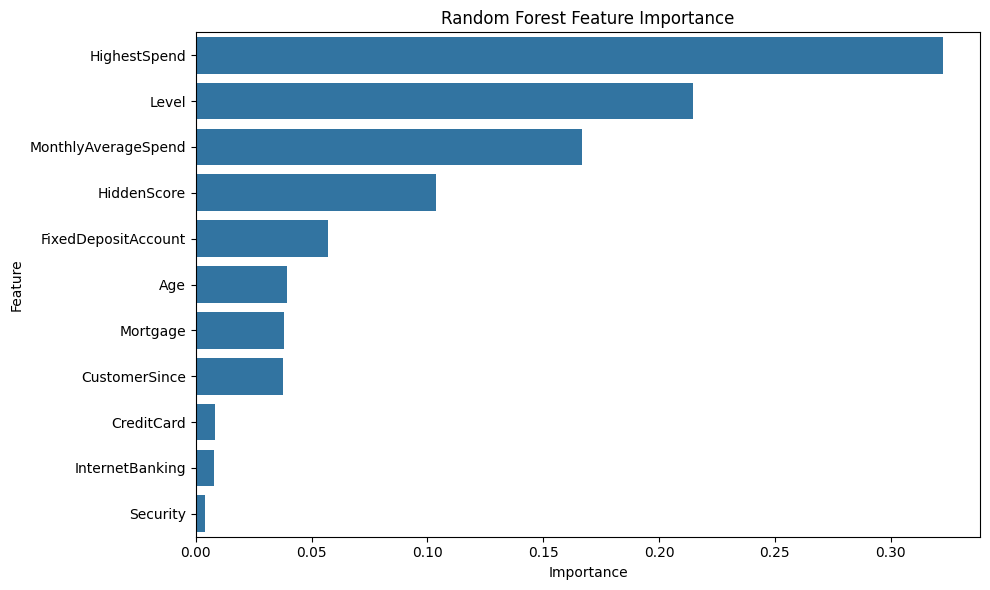

In [81]:
# Random Forest Feature Importance Plot

plt.figure(figsize=(10, 6))

sns.barplot(
    data=rf_importance,
    x="Importance",
    y="Feature"
)

plt.title(
    "Random Forest Feature Importance"
)

plt.tight_layout()

plt.show()

## Hist Gradient Boosting Permutation Importance

In [82]:
# Hist Gradient Boosting Permutation Importance

hgb_importance = permutation_importance(
    hgb_tuned,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1"
)

hgb_importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": hgb_importance.importances_mean
})

hgb_importance_df = (
    hgb_importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(hgb_importance_df)

,Feature,Importance
0,HighestSpend,7.628238e-01
1,Level,3.424872e-01
2,HiddenScore,2.704872e-01
3,MonthlyAverageSpend,7.030080e-02
4,Age,1.922205e-02
5,CustomerSince,5.587728e-03
6,InternetBanking,4.411502e-03
7,Security,2.746557e-03
8,Mortgage,1.457979e-07
9,CreditCard,0.000000e+00


## Interpretation

The two models independently discovered the same story.

### Most Important Features

#### HighestSpend

Rank:

#1 in both models

#### Interpretation:

Customers who have historically made larger transactions are substantially more likely to adopt loan products.

---

#### Level

Rank:

#2 in both models

#### Interpretation:

Higher-value customer segments are significantly more likely to convert into borrowers.

---

#### HiddenScore

Rank:

Top 3–4 in both models

#### Interpretation:

The bank's proprietary customer score contains meaningful predictive information related to borrowing behavior.

---

#### MonthlyAverageSpend

Rank:

Top 4 in both models

#### Interpretation:

Customers with consistently higher spending patterns exhibit greater loan adoption propensity.

## EDA Validation

Notice how the models validated the statistical analysis.

### EDA Findings

Strong predictors:
- HighestSpend
- MonthlyAverageSpend
- Level
- HiddenScore
- FixedDepositAccount

### Model Findings

Strong predictors:
- HighestSpend
- MonthlyAverageSpend
- Level
- HiddenScore

This is exactly what we want.

### Our EDA and ML findings are aligned.

---

### Low Importance Features

Consistently weak:
- Security
- CreditCard
- InternetBanking

This also matches:
- Chi-Square Results
- Not Statistically Significant

### Again validating the earlier analysis.

## Save the model

In [83]:
# Final Production Model

final_model = hgb_tuned

In [84]:
# Save Final Production Model

PROJECT_ROOT = Path.cwd().parent

model_path = PROJECT_ROOT / "models"

model_path.mkdir(
    exist_ok=True
)

joblib.dump(
    final_model,
    model_path / "hist_gradient_boosting_model.joblib"
)

print(f"Model saved successfully: {model_path}")

Model saved successfully: d:\bank-loan-propensity-mlops-deployment\bank-loan-propensity-mlops-deployment\models


In [85]:
# Save Feature Names

import os
import joblib

feature_names_path = os.path.join(
    model_path,
    "feature_names.joblib"
)

joblib.dump(
    list(X_train.columns),
    feature_names_path
)

print(
    f"Feature names saved successfully: {feature_names_path}"
)

Feature names saved successfully: d:\bank-loan-propensity-mlops-deployment\bank-loan-propensity-mlops-deployment\models\feature_names.joblib


## Load Model from Pickle File

In [86]:
MODEL_DIR = Path("../models")

loaded_model = joblib.load(
    MODEL_DIR / "hist_gradient_boosting_model.joblib"
)

feature_names = joblib.load(
    MODEL_DIR / "feature_names.joblib"
)

print("Artifacts loaded successfully.")

Artifacts loaded successfully.


In [87]:
# Make Predictions on Test Data

# Predict class labels
y_pred = loaded_model.predict(X_test)

# Predict probabilities
y_prob = loaded_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [88]:
# Evaluate Loaded Model

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score
)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()

print(f"Accuracy Score : {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC        : {roc_auc_score(y_test, y_prob):.4f}")
print(f"Recall Score   : {recall_score(y_test, y_pred):.4f}")
print(f"Precision Score: {precision_score(y_test, y_pred):.4f}")
print(f"F1-Score       : {f1_score(y_test, y_pred):.4f}")

print("\nConfusion Matrix")
print(cm)

print(f"\nTrue Positives : {tp}")
print(f"True Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")

Accuracy Score : 0.9940
ROC-AUC        : 0.9993
Recall Score   : 0.9583
Precision Score: 0.9787
F1-Score       : 0.9684

Confusion Matrix
[[898   2]
 [  4  92]]

True Positives : 92
True Negatives : 898
False Positives: 2
False Negatives: 4


## Predict for a New Customer

In [89]:
# Predict for a New Customer
# Example customer record
new_customer = pd.DataFrame({
    "Age": [45],
    "CustomerSince": [20],
    "HighestSpend": [67],
    "MonthlyAverageSpend": [2.5],
    "Mortgage": [0],
    "Level": [2],
    "HiddenScore": [3],
    "Security": [0],
    "FixedDepositAccount": [1],
    "InternetBanking": [1],
    "CreditCard": [1]
})

prediction = loaded_model.predict(new_customer)

probability = loaded_model.predict_proba(new_customer)[:, 1]

print("Loan Prediction:", prediction[0])
print("Probability of Loan Adoption:", round(probability[0], 4))

Loan Prediction: 0
Probability of Loan Adoption: 0.0001


## Production-Ready Interpretation

In [90]:
# Production-Ready Interpretation

if prediction[0] == 1:
    print(
        f"High Propensity Customer "
        f"({probability[0]:.2%} probability)"
    )
else:
    print(
        f"Low Propensity Customer "
        f"({probability[0]:.2%} probability)"
    )

Low Propensity Customer (0.01% probability)


# Business Impact Analysis

## Now we move from Machine Learning Metrics to Business Value

## Business Objective

The bank wants to:

Increase borrower conversion rates through focused digital marketing while maintaining the same campaign budget.

---

### Hist Gradient Boosting Tuned

##### Out of: 96 actual borrowers
- the model identifies: 92 borrowers
- and misses: 4 borrowers
- while incorrectly targeting: 2 non-borrowers


### Business Interpretation

##### For every 996 customers

the model would:
- Correctly identify: 92 likely borrowers
- Miss: 4 potential borrowers
- Waste marketing effort on: 2 customers

## Cost of False Positives vs False Negatives

## This section is very important.

### False Positive

Prediction: Will Borrow

Reality: Will Not Borrow

Impact: Minor marketing cost

Examples:
- Email campaign
- Phone call
- Promotion offer

Cost is relatively low.

---

### False Negative

Prediction: Will Not Borrow

Reality: Will Borrow

Impact:
- Lost revenue opportunity
- The customer is never targeted.
- Potential interest revenue is lost.

## Conclusion

### For this banking problem:

False Negative

is more expensive than:

False Positive

which explains why Recall was treated as a critical evaluation metric throughout model development.

# Final Model Selection

## Candidate Models

| Rank | Model | ROC-AUC | Precision | Recall | F1-Score | False Positives | False Negatives |
|------:|--------|---------:|----------:|-------:|---------:|----------------:|----------------:|
| 1 | Hist Gradient Boosting (Tuned) | 99.93% | 97.87% | 95.83% | 96.84% | 2 | 4 |
| 2 | Random Forest (Baseline) | 99.91% | 98.90% | 93.75% | 96.26% | 1 | 6 |
| 3 | Random Forest + SMOTE + Undersampling | 99.90% | 92.23% | 98.96% | 95.48% | 8 | 1 |

## Model Selection Framework

As a professional Data Scientist, model selection should not be based on a single metric.

## The evaluation considered:

### Predictive Performance
- Precision
- Recall
- F1 Score
- ROC-AUC

---

### Business Impact
- False Positives
- False Negatives

---

### Generalization
- Train-Test Accuracy Gap
- Overfitting Assessment

---

### Interpretability & Deployment Readiness
- Model Stability
- Scalability
- Production Suitability

## Final Production Model

Hist Gradient Boosting - Tuned

### Justification

The Hist Gradient Boosting model achieved:
- Highest F1 Score (96.84%)
- Highest ROC-AUC (99.93%)
- Excellent Precision (97.87%)
- Excellent Recall (95.83%)
- Low False Positive rate
- Low False Negative rate
- Strong generalization performance
- No evidence of significant overfitting

The model provides the best balance between identifying potential borrowers and minimizing unnecessary marketing outreach.

---

## Business Alternative Model

Random Forest + SMOTE + Undersampling

### Justification

This model achieved:
- Highest Recall (98.96%)
- Lowest False Negatives (1)

### If the business objective shifts toward:

Capture every possible borrower

and management is willing to tolerate additional marketing costs, this model would be the preferred choice.

## Recommended Business Strategy

## Standard Marketing Campaign

Use:

Hist Gradient Boosting - Tuned

Reason:
- Balanced performance and efficient marketing spend.

## Aggressive Growth Campaign

Use:

Random Forest + SMOTE + Undersampling

Reason:
- Maximizes borrower identification and minimizes missed opportunities.

# Prescriptive Analysis

## Key Customer Insights

This is where you convert ML findings into business recommendations.

### Insight 1: High-Value Transactions Drive Borrowing Behavior

HighestSpend emerged as the most influential predictor across both Random Forest and Hist Gradient Boosting models.

#### Recommendation

Target customers who demonstrate large transaction behavior with personalized loan offers.

---

### Insight 2: Customer Segmentation Matters

Level consistently ranked among the strongest predictors.

#### Recommendation

Prioritize marketing efforts toward higher-value customer segments.

---

### Insight 3: Spending Consistency Indicates Loan Potential

MonthlyAverageSpend was a strong predictor of loan ownership.

#### Recommendation

Develop campaigns focused on customers with sustained spending activity.

---

### Insight 4: HiddenScore Contains Valuable Information

The bank's proprietary customer scoring mechanism contributed significantly to prediction performance.

#### Recommendation

Integrate HiddenScore into future borrower targeting strategies.

---

### Insight 5: Traditional Banking Products Have Limited Influence

Security, InternetBanking, and CreditCard contributed little predictive value.

#### Recommendation

Avoid relying on these features as primary targeting criteria.

# Deployment Recommendation

## Recommended Deployment Architecture

```text
Customer Data
      ↓
Data Validation
      ↓
Feature Engineering Pipeline
      ↓
Hist Gradient Boosting Model
      ↓
Probability Scoring
      ↓
Borrower Likelihood Ranking
      ↓
Marketing Campaign System
```

# Operational Recommendation

## Rather than making a simple:

Borrow vs Not Borrow prediction,

## generate:

- Probability Scores
- and rank customers from highest to lowest likelihood.

Marketing teams can then focus budget on the top-ranked customers.

# Project Conclusion

The objective of this project was to develop a machine learning solution capable of identifying liability customers who are most likely to convert into asset customers by adopting loan products. Following data understanding, cleaning, exploratory analysis, feature engineering, model benchmarking, class imbalance handling, and hyperparameter optimization, multiple machine learning algorithms were evaluated.

Hist Gradient Boosting emerged as the strongest overall model, achieving an F1 Score of 96.84%, a Recall of 95.83%, and a ROC-AUC of 99.93%. The model demonstrated excellent generalization performance and provided the best balance between identifying potential borrowers and minimizing unnecessary marketing outreach.

Feature importance analysis revealed that HighestSpend, Level, HiddenScore, and MonthlyAverageSpend were the most influential drivers of loan adoption. These findings indicate that customer spending behavior and internal customer segmentation metrics play a significantly greater role in predicting borrowing behavior than demographic characteristics or basic banking service usage.

The resulting solution enables the bank to prioritize high-potential customers, improve marketing efficiency, reduce acquisition costs, and support data-driven digital marketing initiatives. By integrating the model into campaign workflows, the bank can increase borrower conversion rates while maintaining effective allocation of marketing resources.